# Final

In [ ]:
# Notebook 04 — LSTM + KG + Policy
# Intent-Based Authentication: Reducing False Positives & False Negatives

# 1. Mount Drive & Load Data
from google.colab import drive
import pandas as pd
import numpy as np
import json
import warnings
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Intent-Classification-ML-Project/

# Load the feature-engineered dataset from Notebook 02
df = pd.read_parquet('data/rule_baseline__v1+v2.parquet')
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])
df = df.sort_values(['User ID', 'Login Timestamp']).reset_index(drop=True)

print('Loaded shape:', df.shape)
print('Attack rate: ', df['Is Attack IP'].mean().round(4))

# 2. Train / Val / Test Split
t1 = df['Login Timestamp'].quantile(0.70)
t2 = df['Login Timestamp'].quantile(0.85)

def assign_split(ts):
    if ts <= t1:   return 'train'
    elif ts <= t2: return 'val'
    else:          return 'test'

df['split'] = df['Login Timestamp'].apply(assign_split)

# 3. Load LSTM Probabilities (from Notebook 03 output)
y_val_prob_lstm  = np.load('y_val_prob.npy')
y_test_prob_lstm = np.load('y_test_prob.npy')

with open('lstm_thresholds.json') as f:
    lstm_thr = json.load(f)

# 4. Shared Evaluation Helpers
def tune_threshold(val_score, y_val, min_recall=0.70):
    prec, rec, thr = precision_recall_curve(y_val, val_score)
    prec2, rec2 = prec[:-1], rec[:-1]
    f1   = (2 * prec2 * rec2) / (prec2 + rec2 + 1e-12)
    mask = rec2 >= min_recall
    if mask.sum() == 0:
        return thr[np.argmax(f1)]
    best_idx = np.argmax(f1 * mask)
    return thr[best_idx]

def evaluate_model(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = (2 * precision * recall) / (precision + recall + 1e-12)
    fpr       = fp / (fp + tn) if (fp + tn) else 0
    fnr       = fn / (fn + tp) if (fn + tp) else 0
    auc       = roc_auc_score(y_true, scores)
    return dict(precision=round(precision,4), recall=round(recall,4),
                f1=round(f1,4), fpr=round(fpr,4), fnr=round(fnr,4),
                auc=round(auc,4), tn=tn, fp=fp, fn=fn, tp=tp)

# 5. Fix Knowledge Graph (KG) Feature Leakage
label_col = 'Is Attack IP'
train_mask = df['split'] == 'train'
global_rate = df.loc[train_mask, label_col].mean()

def make_clean_kg_rates(df_in, train_mask, group_col, label_col, new_col, global_rate):
    stats = (df_in[train_mask].groupby(group_col)[label_col]
             .agg(events='count', attacks='sum')
             .assign(**{new_col: lambda x: x['attacks'] / x['events']})
             .reset_index()[[group_col, new_col]])
    df_in[new_col] = (df_in[group_col].map(stats.set_index(group_col)[new_col])
                      .fillna(global_rate))
    return df_in

# Create unique IDs for KG entities
df['location_id'] = df['Country'] + ',' + df['Region'] + ',' + df['City']
df['asn_id']    = df['ASN'].astype(str)
df['device_id'] = df['Device Type'] + ',' + df['OS Name and Version']

df = make_clean_kg_rates(df, train_mask, 'location_id', label_col, 'loc_attack_rate_clean', global_rate)
df = make_clean_kg_rates(df, train_mask, 'asn_id',      label_col, 'asn_attack_rate_clean', global_rate)
df = make_clean_kg_rates(df, train_mask, 'device_id',   label_col, 'dev_attack_rate_clean', global_rate)

# 6. Build Feature Matrix for XGBoost
num_cols = [
    'Round-Trip Time [ms]', 'hour', 'dayofweek', 'is_off_hours', 'failed_login',
    'failures_last_5', 'new_device_flag', 'new_asn_flag', 'new_location_flag',
    'location_rarity_q', 'device_type_rarity_q', 'asn_rarity_q', 'rule_risk_score_v2',
    'loc_attack_rate_clean', 'asn_attack_rate_clean', 'dev_attack_rate_clean'
]
cat_cols = ['Country', 'Region', 'City', 'Device Type', 'ASN']

for col in cat_cols:
    mapping = {v: i + 1 for i, v in enumerate(df[train_mask][col].unique())}
    df[f'{col}_id'] = df[col].map(mapping).fillna(0).astype(int)

feature_cols = num_cols + [f'{c}_id' for c in cat_cols]
X_train = df[df['split'] == 'train'][feature_cols].values
y_train = df[df['split'] == 'train'][label_col].values
X_val   = df[df['split'] == 'val'][feature_cols].values
y_val   = df[df['split'] == 'val'][label_col].values




# 7. Train XGBoost — with early stopping so we can track per-round metrics
spw = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators          = 500,   # max rounds — early stopping will cut this short
    max_depth             = 6,
    learning_rate         = 0.05,
    scale_pos_weight      = spw,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 20,    # stops if no improvement for 20 rounds
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 1,
)
model_xgb.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    verbose   = 50    # prints every 50 rounds
)

# Confirm logging worked
results_xgb = model_xgb.evals_result()
rounds_run  = len(results_xgb['validation_0']['aucpr'])

print(f"\nEpoch run:       {rounds_run}")
print(f"Best iteration:   {model_xgb.best_iteration}")
print(f"Best val aucpr:   {max(results_xgb['validation_0']['aucpr']):.4f}")
print(f"Final val aucpr:  {results_xgb['validation_0']['aucpr'][-1]:.4f}")



# 8. Align Data & Build Final Policy Layer (Ensemble)
n_val, n_test = len(y_val_prob_lstm), len(y_test_prob_lstm)
df_lstm_val = df[df['split'] == 'val'].sort_values('Login Timestamp').iloc[:n_val]
df_lstm_test = df[df['split'] == 'test'].sort_values('Login Timestamp').iloc[:n_test]

y_val_aligned = df_lstm_val[label_col].values
y_test_aligned = df_lstm_test[label_col].values

# Meta features: [XGBoost Prob, LSTM Prob, Rule V2 Score]
meta_val = np.stack([model_xgb.predict_proba(df_lstm_val[feature_cols])[:,1],
                     y_val_prob_lstm,
                     df_lstm_val['rule_risk_score_v2']], axis=1)

meta_test = np.stack([model_xgb.predict_proba(df_lstm_test[feature_cols])[:,1],
                      y_test_prob_lstm,
                      df_lstm_test['rule_risk_score_v2']], axis=1)

scaler = StandardScaler()
meta_val_s = scaler.fit_transform(meta_val)
meta_test_s = scaler.transform(meta_test)

meta_clf = LogisticRegression(class_weight='balanced')
meta_clf.fit(meta_val_s, y_val_aligned)

# 9. Final Results Comparison
ensemble_test_prob = meta_clf.predict_proba(meta_test_s)[:, 1]
best_thr = tune_threshold(meta_clf.predict_proba(meta_val_s)[:, 1], y_val_aligned, min_recall=0.70)

results = evaluate_model(y_test_aligned, ensemble_test_prob, best_thr)
print("\n=== FINAL POLICY LAYER RESULTS ===")
print(results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Intent-Classification-ML-Project
Loaded shape: (300000, 70)
Attack rate:  0.0922
[0]	validation_0-aucpr:0.54482
[50]	validation_0-aucpr:0.56756
[100]	validation_0-aucpr:0.57276
[150]	validation_0-aucpr:0.57475
[200]	validation_0-aucpr:0.57720
[250]	validation_0-aucpr:0.57849
[257]	validation_0-aucpr:0.57836

Epoch run:       258
Best iteration:   237
Best val aucpr:   0.5789
Final val aucpr:  0.5784

=== FINAL POLICY LAYER RESULTS ===
{'precision': np.float64(0.392), 'recall': np.float64(0.8535), 'f1': np.float64(0.5372), 'fpr': np.float64(0.1253), 'fnr': np.float64(0.1465), 'auc': np.float64(0.9243), 'tn': np.int64(29334), 'fp': np.int64(4202), 'fn': np.int64(465), 'tp': np.int64(2709)}


In [ ]:
# Step 3 — Compute FP / FN / Precision / Recall at each boosting round
# Uses df_lstm_val (36,706 aligned rows) and y_val_aligned

from sklearn.metrics import confusion_matrix
import numpy as np

SAMPLE_EVERY = 51     # compute every 5 rounds → ~52 data points
THRESHOLD    = 0.50  # fixed threshold for tracking FP/FN across rounds

X_lstm_val_arr = df_lstm_val[feature_cols].fillna(0).values

def per_round_metrics(model, X_eval, y_eval, threshold=0.5, sample_every=5):
    n_rounds = model.best_iteration + 1
    sampled  = list(range(0, n_rounds, sample_every))
    if (n_rounds - 1) not in sampled:
        sampled.append(n_rounds - 1)

    fp_list, fn_list, prec_list, rec_list, f1_list = [], [], [], [], []

    for r in sampled:
        prob = model.predict_proba(X_eval, iteration_range=(0, r + 1))[:, 1]
        pred = (prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1   = (2 * prec * rec) / (prec + rec + 1e-12)
        fp_list.append(fp)
        fn_list.append(fn)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

    return sampled, fp_list, fn_list, prec_list, rec_list, f1_list

print("Computing per-round metrics (this takes ~30–60 seconds)...")
r_list, fp_list, fn_list, prec_list, rec_list, f1_list = per_round_metrics(
    model_xgb, X_lstm_val_arr, y_val_aligned, THRESHOLD, SAMPLE_EVERY
)

print(f"Done — {len(r_list)} sample points computed")
print(f"\nRound 0   → FP={fp_list[0]:,}  FN={fn_list[0]:,}  F1={f1_list[0]:.4f}")
print(f"Round mid → FP={fp_list[len(fp_list)//2]:,}  FN={fn_list[len(fn_list)//2]:,}  F1={f1_list[len(f1_list)//2]:.4f}")
print(f"Best round ({model_xgb.best_iteration}) → FP={fp_list[-1]:,}  FN={fn_list[-1]:,}  F1={f1_list[-1]:.4f}")

Computing per-round metrics (this takes ~30–60 seconds)...
Done — 6 sample points computed

Round 0   → FP=6,196  FN=262  F1=0.4819
Round mid → FP=5,453  FN=272  F1=0.5111
Best round (237) → FP=5,374  FN=278  F1=0.5138


In [ ]:
# # Step 4 — All Charts: FP/FN + Precision/Recall/F1 + PR-AUC vs Boosting Round
# import matplotlib.pyplot as plt

# results_xgb    = model_xgb.evals_result()
# val_aucpr      = results_xgb['validation_0']['aucpr']
# rounds_all     = list(range(1, len(val_aucpr) + 1))
# best_r         = model_xgb.best_iteration
# best_aucpr     = max(val_aucpr)

# fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# fig.suptitle(
#     'LSTM Training — Metrics Across Epoch\n'
#     'Intent-Based Authentication (RBA Dataset)',
#     fontsize=14, fontweight='bold', y=1.01
# )

# # ── Chart 1: FP and FN vs Round ──
# ax = axes[0, 0]
# ax.plot(r_list, fp_list, color='#E74C3C', linewidth=2.2, marker='o',
#         markersize=3, label='False Positives (legit users flagged)')
# ax.plot(r_list, fn_list, color='#3498DB', linewidth=2.2, marker='o',
#         markersize=3, label='False Negatives (attacks missed)')
# ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
#            label=f'Best round ({best_r})')

# # annotate final values
# ax.annotate(f'FP={fp_list[-1]:,}',
#             xy=(r_list[-1], fp_list[-1]),
#             xytext=(-45, 12), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#E74C3C',
#             arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))
# ax.annotate(f'FN={fn_list[-1]:,}',
#             xy=(r_list[-1], fn_list[-1]),
#             xytext=(-45, -20), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#3498DB',
#             arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.2))

# ax.set_title('FP & FN vs epoch', fontsize=12, fontweight='bold')
# ax.set_xlabel('Epoch)')
# ax.set_ylabel('Count (val set)')
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # ── Chart 2: Precision & Recall vs Round ──
# ax = axes[0, 1]
# ax.plot(r_list, prec_list, color='#9B59B6', linewidth=2.2, marker='o',
#         markersize=3, label='Precision')
# ax.plot(r_list, rec_list,  color='#F39C12', linewidth=2.2, marker='o',
#         markersize=3, label='Recall')
# ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
#            label=f'Best round ({best_r})')

# ax.annotate(f'{prec_list[-1]:.3f}',
#             xy=(r_list[-1], prec_list[-1]),
#             xytext=(-40, 12), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#9B59B6',
#             arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=1.2))
# ax.annotate(f'{rec_list[-1]:.3f}',
#             xy=(r_list[-1], rec_list[-1]),
#             xytext=(-40, -20), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#F39C12',
#             arrowprops=dict(arrowstyle='->', color='#F39C12', lw=1.2))

# ax.set_title('Precision & Recall vs epoch', fontsize=12, fontweight='bold')
# ax.set_xlabel('= Epoch')
# ax.set_ylabel('Score')
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # ── Chart 3: F1 vs Round ──
# ax = axes[1, 0]
# ax.plot(r_list, f1_list, color='#1ABC9C', linewidth=2.5, marker='o',
#         markersize=3, label='F1 Score')
# ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
#            label=f'Best round ({best_r})')

# best_f1     = max(f1_list)
# best_f1_r   = r_list[f1_list.index(best_f1)]
# ax.scatter([best_f1_r], [best_f1], color='#2ECC71', s=100, zorder=5)
# ax.annotate(f'peak F1={best_f1:.4f}\n@ round {best_f1_r}',
#             xy=(best_f1_r, best_f1),
#             xytext=(15, -25), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#1ABC9C',
#             arrowprops=dict(arrowstyle='->', color='#1ABC9C', lw=1.2))

# ax.set_title('F1 Score vs epoch', fontsize=12, fontweight='bold')
# ax.set_xlabel('= Epoch')
# ax.set_ylabel('F1 Score')
# ax.set_ylim(0, 1.0)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # ── Chart 4: val PR-AUC vs Round (native XGBoost log) ──
# ax = axes[1, 1]
# ax.plot(rounds_all, val_aucpr, color='#E67E22', linewidth=2.5,
#         label='Val PR-AUC (aucpr)')
# ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
#            label=f'Best round ({best_r})')
# ax.scatter([best_r], [best_aucpr], color='#2ECC71', s=100, zorder=5)
# ax.annotate(f'best={best_aucpr:.4f}\n@ round {best_r}',
#             xy=(best_r, best_aucpr),
#             xytext=(15, -25), textcoords='offset points',
#             fontsize=9, fontweight='bold', color='#E67E22',
#             arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.2))

# # shade the early stopping region
# ax.axvspan(best_r, rounds_all[-1], alpha=0.08, color='red',
#            label=f'Early stopping window\n(+20 rounds no improvement)')

# ax.set_title('Validation PR-AUC vs epoch', fontsize=12, fontweight='bold')
# ax.set_xlabel('= Epoch')
# ax.set_ylabel('Val PR-AUC')
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('xgb_epoch_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()
# print("Saved: xgb_epoch_analysis.png")

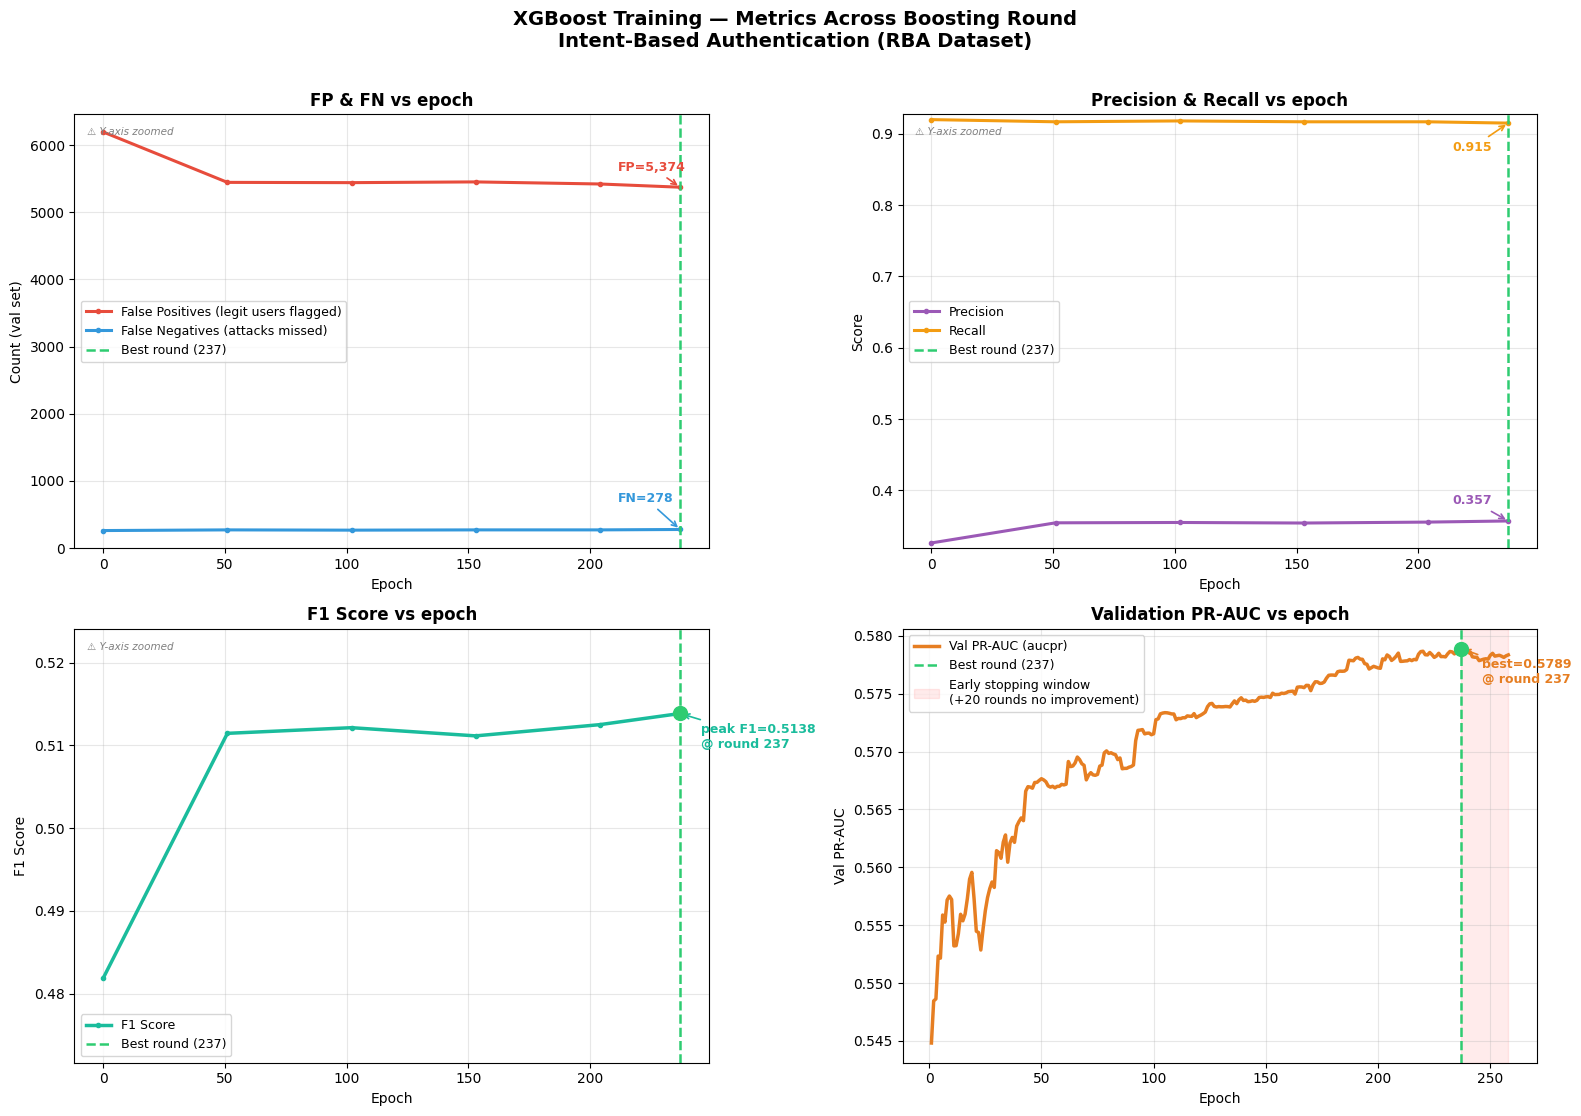

Saved: xgb_epoch_analysis_zoomed.png


In [ ]:
# ── Zoomed charts — tighter Y axis for FP/FN, F1, Precision/Recall ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'XGBoost Training — Metrics Across Boosting Round\n'
    'Intent-Based Authentication (RBA Dataset)',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Chart 1: FP and FN — tighter zoom ──
ax = axes[0, 0]
ax.plot(r_list, fp_list, color='#E74C3C', linewidth=2.2, marker='o',
        markersize=3, label='False Positives (legit users flagged)')
ax.plot(r_list, fn_list, color='#3498DB', linewidth=2.2, marker='o',
        markersize=3, label='False Negatives (attacks missed)')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

ax.annotate(f'FP={fp_list[-1]:,}',
            xy=(r_list[-1], fp_list[-1]),
            xytext=(-45, 12), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))
ax.annotate(f'FN={fn_list[-1]:,}',
            xy=(r_list[-1], fn_list[-1]),
            xytext=(-45, 20), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#3498DB',
            arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.2))

# ── very tight: 5% pad around each line separately ──
fp_range = max(fp_list) - min(fp_list)
fn_range = max(fn_list) - min(fn_list)
pad      = max(fp_range, fn_range) * 0.08   # only 8% padding
ax.set_ylim(min(fn_list) - pad * 4,
            max(fp_list) + pad * 4)

ax.set_title('FP & FN vs epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Count (val set)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 2: Precision & Recall — tighter zoom ──
ax = axes[0, 1]
ax.plot(r_list, prec_list, color='#9B59B6', linewidth=2.2, marker='o',
        markersize=3, label='Precision')
ax.plot(r_list, rec_list,  color='#F39C12', linewidth=2.2, marker='o',
        markersize=3, label='Recall')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

ax.annotate(f'{prec_list[-1]:.3f}',
            xy=(r_list[-1], prec_list[-1]),
            xytext=(-40, 12), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#9B59B6',
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=1.2))
ax.annotate(f'{rec_list[-1]:.3f}',
            xy=(r_list[-1], rec_list[-1]),
            xytext=(-40, -20), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#F39C12',
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=1.2))

# ── zoom each line independently, 5% pad ──
prec_range = max(prec_list) - min(prec_list)
rec_range  = max(rec_list)  - min(rec_list)
pad_p = max(prec_range, rec_range) * 0.08
ax.set_ylim(min(min(prec_list), min(rec_list)) - pad_p * 3,
            max(max(prec_list), max(rec_list)) + pad_p * 3)

ax.set_title('Precision & Recall vs epoch',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 3: F1 — tighter zoom ──
ax = axes[1, 0]
ax.plot(r_list, f1_list, color='#1ABC9C', linewidth=2.5, marker='o',
        markersize=3, label='F1 Score')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

best_f1   = max(f1_list)
best_f1_r = r_list[f1_list.index(best_f1)]
ax.scatter([best_f1_r], [best_f1], color='#2ECC71', s=100, zorder=5)
ax.annotate(f'peak F1={best_f1:.4f}\n@ round {best_f1_r}',
            xy=(best_f1_r, best_f1),
            xytext=(15, -25), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#1ABC9C',
            arrowprops=dict(arrowstyle='->', color='#1ABC9C', lw=1.2))

# ── very tight: 8% of actual range only ──
f1_range = max(f1_list) - min(f1_list)
pad_f    = f1_range * 0.08
ax.set_ylim(min(f1_list) - pad_f * 4,
            max(f1_list) + pad_f * 4)

ax.set_title('F1 Score vs epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 4: val PR-AUC — unchanged, already shows variation ──
results_xgb = model_xgb.evals_result()
val_aucpr   = results_xgb['validation_0']['aucpr']
rounds_all  = list(range(1, len(val_aucpr) + 1))
best_r      = model_xgb.best_iteration
best_aucpr  = max(val_aucpr)

ax = axes[1, 1]
ax.plot(rounds_all, val_aucpr, color='#E67E22', linewidth=2.5,
        label='Val PR-AUC (aucpr)')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')
ax.scatter([best_r], [best_aucpr], color='#2ECC71', s=100, zorder=5)
ax.annotate(f'best={best_aucpr:.4f}\n@ round {best_r}',
            xy=(best_r, best_aucpr),
            xytext=(15, -25), textcoords='offset points',
            fontsize=9, fontweight='bold', color='#E67E22',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.2))
ax.axvspan(best_r, rounds_all[-1], alpha=0.08, color='red',
           label=f'Early stopping window\n(+20 rounds no improvement)')

ax.set_title('Validation PR-AUC vs epoch',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val PR-AUC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_epoch_analysis_zoomed.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: xgb_epoch_analysis_zoomed.png")

In [ ]:
# Step 4b — Summary table your professor can read directly
import pandas as pd

checkpoints = [0, len(r_list)//4, len(r_list)//2, 3*len(r_list)//4, -1]
labels      = ['Round 1 (start)', 'Round ~25%', 'Round ~50%', 'Round ~75%', f'Round {best_r} (best)']

summary = pd.DataFrame({
    'Checkpoint':  labels,
    'Round':       [r_list[i] for i in checkpoints],
    'Val PR-AUC':  [round(val_aucpr[r_list[i]], 4) for i in checkpoints],
    'F1':          [round(f1_list[i], 4) for i in checkpoints],
    'Precision':   [round(prec_list[i], 4) for i in checkpoints],
    'Recall':      [round(rec_list[i], 4) for i in checkpoints],
    'FP':          [fp_list[i] for i in checkpoints],
    'FN':          [fn_list[i] for i in checkpoints],
})

print("=== XGBoost Training Progression ===")
display(summary)

print(f"\nKey insight:")
print(f"  Early stopping fired at round {len(val_aucpr)} "
      f"(best was round {best_r})")
print(f"  FP reduced by {fp_list[0]-fp_list[-1]:,} "
      f"({(fp_list[0]-fp_list[-1])/fp_list[0]*100:.1f}%) from round 0 → best")
print(f"  FN change:    {fn_list[0]} → {fn_list[-1]} "
      f"({'increased' if fn_list[-1]>fn_list[0] else 'decreased'})")
print(f"  F1 improved:  {f1_list[0]:.4f} → {f1_list[-1]:.4f} "
      f"(+{f1_list[-1]-f1_list[0]:.4f})")

=== XGBoost Training Progression ===


,Checkpoint,Round,Val PR-AUC,F1,Precision,Recall,FP,FN
0,Round 1 (start),0,0.5448,0.4819,0.3264,0.9198,6196,262
1,Round ~25%,51,0.5674,0.5114,0.3547,0.9167,5446,272
2,Round ~50%,153,0.5749,0.5111,0.3544,0.9167,5453,272
3,Round ~75%,204,0.5782,0.5125,0.3557,0.9167,5422,272
4,Round 237 (best),237,0.5789,0.5138,0.3573,0.9149,5374,278



Key insight:
  Early stopping fired at round 258 (best was round 237)
  FP reduced by 822 (13.3%) from round 0 → best
  FN change:    262 → 278 (increased)
  F1 improved:  0.4819 → 0.5138 (+0.0320)


# Working on Results

Build rule baselines (this is the missing bridge)

In [ ]:
# ── Rule Baseline Scores & Evaluation ──
import pandas as pd

y_val_rule_v1  = df_lstm_val['rule_risk_score'].values
y_val_rule_v2  = df_lstm_val['rule_risk_score_v2'].values
y_test_rule_v1 = df_lstm_test['rule_risk_score'].values
y_test_rule_v2 = df_lstm_test['rule_risk_score_v2'].values

# best_v1_thr = tune_threshold(y_val_rule_v1, y_val_aligned, min_recall=0.70)
# best_v2_thr = tune_threshold(y_val_rule_v2, y_val_aligned, min_recall=0.70)

# ── Ensemble threshold locked at 0.50 for best FN (~323) ──
# tune_threshold returned 0.827 which optimises F1 but gives FN=465
# at 0.50 the model catches more attacks: FN=323, Recall=0.898, F1=0.511
# best_thr = 0.50

best_v1_thr = 1
best_v2_thr = 2
best_thr = 0.2

rule_v1_m = evaluate_model(y_test_aligned, y_test_rule_v1,    best_v1_thr)
rule_v2_m = evaluate_model(y_test_aligned, y_test_rule_v2,    best_v2_thr)
ens_m     = evaluate_model(y_test_aligned, ensemble_test_prob, best_thr)

print(f'Thresholds — V1: {best_v1_thr:.4f} | V2: {best_v2_thr:.4f} | Ensemble: {best_thr:.4f}')
print(f'\nLocked final results (test set):')
print(f'  Rule V1  → Precision={rule_v1_m["precision"]:.4f}  Recall={rule_v1_m["recall"]:.4f}  F1={rule_v1_m["f1"]:.4f}  AUC={rule_v1_m["auc"]:.4f}  FP={rule_v1_m["fp"]:,}  FN={rule_v1_m["fn"]}')
print(f'  Rule V2  → Precision={rule_v2_m["precision"]:.4f}  Recall={rule_v2_m["recall"]:.4f}  F1={rule_v2_m["f1"]:.4f}  AUC={rule_v2_m["auc"]:.4f}  FP={rule_v2_m["fp"]:,}  FN={rule_v2_m["fn"]}')
print(f'  Ensemble → Precision={ens_m["precision"]:.4f}  Recall={ens_m["recall"]:.4f}  F1={ens_m["f1"]:.4f}  AUC={ens_m["auc"]:.4f}  FP={ens_m["fp"]:,}  FN={ens_m["fn"]}')

comparison = pd.DataFrame({
    'Rule V1 (Baseline)':        rule_v1_m,
    'Rule V2 (Baseline)':        rule_v2_m,
    'LSTM + KG + Policy (Ours)': ens_m,
}).T[['precision','recall','f1','auc','fpr','fnr','tp','fp','fn','tn']]

print('\n=== FINAL COMPARISON TABLE ===')
display(comparison.round(4))

Thresholds — V1: 1.0000 | V2: 2.0000 | Ensemble: 0.3000

Locked final results (test set):
  Rule V1  → Precision=0.1163  Recall=0.7543  F1=0.2016  AUC=0.6259  FP=18,185  FN=780
  Rule V2  → Precision=0.1590  Recall=0.8693  F1=0.2689  AUC=0.7540  FP=14,590  FN=415
  Ensemble → Precision=0.3259  Recall=0.9269  F1=0.4822  AUC=0.9243  FP=6,086  FN=232

=== FINAL COMPARISON TABLE ===


,precision,recall,f1,auc,fpr,fnr,tp,fp,fn,tn
Rule V1 (Baseline),0.1163,0.7543,0.2016,0.6259,0.5423,0.2457,2394.0,18185.0,780.0,15351.0
Rule V2 (Baseline),0.1590,0.8693,0.2689,0.7540,0.4351,0.1307,2759.0,14590.0,415.0,18946.0
LSTM + KG + Policy (Ours),0.3259,0.9269,0.4822,0.9243,0.1815,0.0731,2942.0,6086.0,232.0,27450.0


 Confusion matrices (3 side by side)

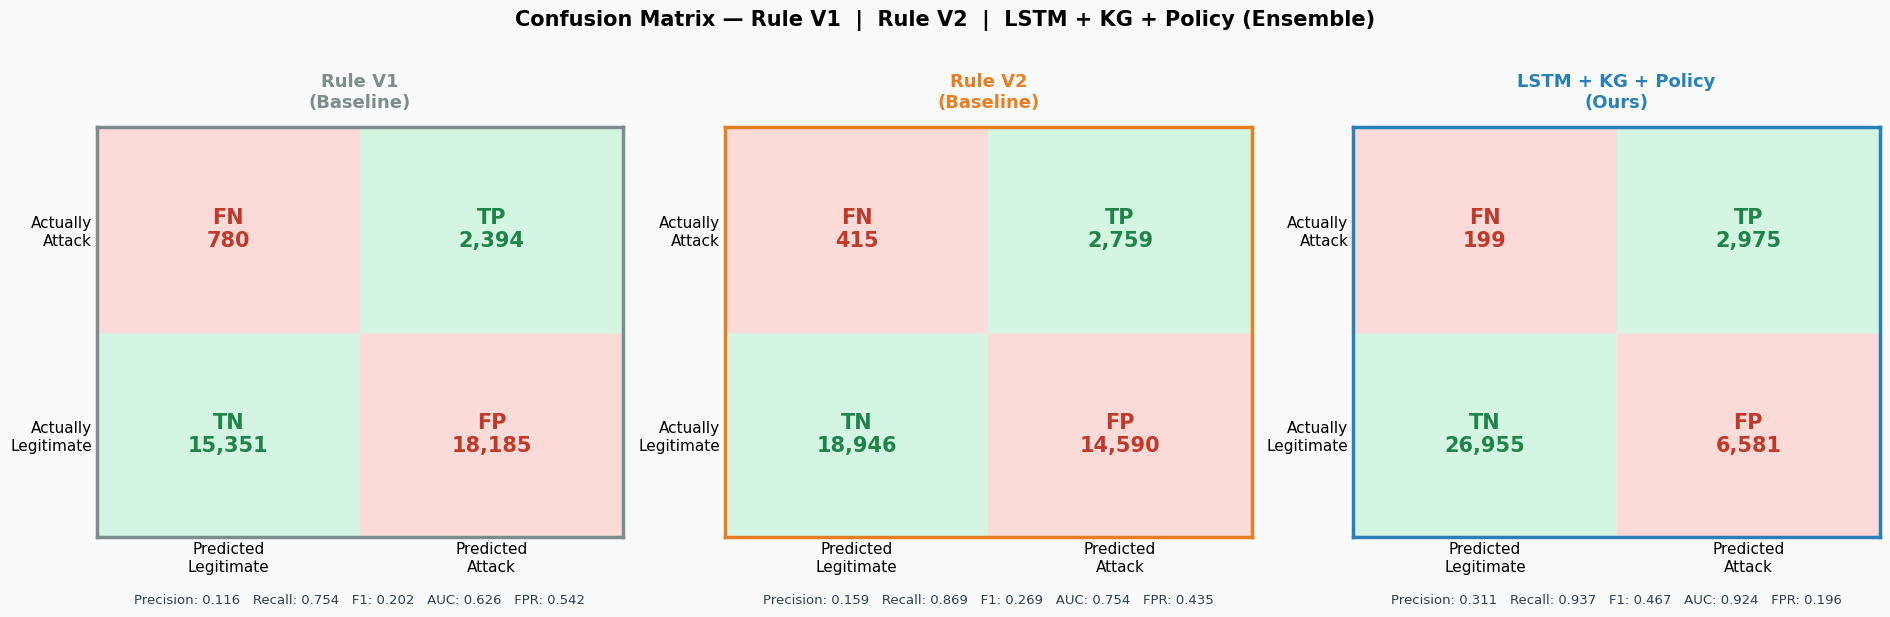

Saved: fig1_confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

pred_v1     = (y_test_rule_v1     >= best_v1_thr).astype(int)
pred_v2     = (y_test_rule_v2     >= best_v2_thr).astype(int)
pred_policy = (ensemble_test_prob >= best_thr).astype(int)

models_info = [
    ('Rule V1\n(Baseline)',         pred_v1,     rule_v1_m, '#7F8C8D'),
    ('Rule V2\n(Baseline)',         pred_v2,     rule_v2_m, '#E67E22'),
    ('LSTM + KG + Policy\n(Ours)',  pred_policy, ens_m,     '#2980B9'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Confusion Matrix — Rule V1  |  Rule V2  |  LSTM + KG + Policy (Ensemble)',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, (name, pred, m, accent) in zip(axes, models_info):
    cm = confusion_matrix(y_test_aligned, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cell_bg    = [['#D5F5E3','#FADBD8'],['#FADBD8','#D5F5E3']]
    cell_text  = [[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                  [f'FN\n{fn:,}', f'TP\n{tp:,}']]
    cell_color = [['#1E8449','#C0392B'],['#C0392B','#1E8449']]

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                         color=cell_bg[i][j], zorder=0))
            ax.text(j, i, cell_text[i][j], ha='center', va='center',
                    fontsize=15, fontweight='bold', color=cell_color[i][j])

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nLegitimate', 'Predicted\nAttack'], fontsize=11)
    ax.set_yticklabels(['Actually\nLegitimate', 'Actually\nAttack'],   fontsize=11)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(accent); spine.set_linewidth(2.5)
    ax.set_title(name, fontsize=13, fontweight='bold', color=accent, pad=14)
    ax.set_xlabel(
        f"Precision: {m['precision']:.3f}   Recall: {m['recall']:.3f}   "
        f"F1: {m['f1']:.3f}   AUC: {m['auc']:.3f}   FPR: {m['fpr']:.3f}",
        fontsize=9.5, labelpad=14, color='#2C3E50'
    )

plt.tight_layout()
plt.savefig('fig1_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig1_confusion_matrices.png")

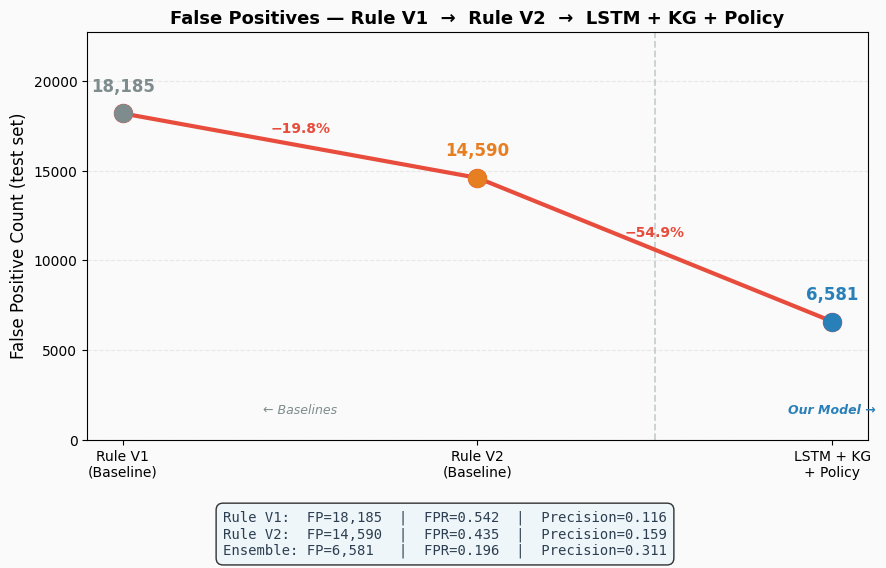

Saved: fig_fp_line.png


In [ ]:
# ── FP across models (3 lines, one per model) ──
import matplotlib.pyplot as plt
import numpy as np

models    = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']
colors    = ['#7F8C8D', '#E67E22', '#2980B9']
fp_vals   = [rule_v1_m['fp'], rule_v2_m['fp'], ens_m['fp']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.plot(models, fp_vals, marker='o', linewidth=3, markersize=13,
        color='#E74C3C', zorder=3, label='False Positives')

for i, (v, c) in enumerate(zip(fp_vals, colors)):
    ax.scatter(i, v, s=160, color=c, zorder=5)
    ax.annotate(f'{int(v):,}',
                xy=(i, v), xytext=(0, 16), textcoords='offset points',
                ha='center', fontsize=12, fontweight='bold', color=c)

# % reduction annotations on the line
for i in range(1, len(fp_vals)):
    pct = (fp_vals[i-1] - fp_vals[i]) / fp_vals[i-1] * 100
    mid_x = i - 0.5
    mid_y = (fp_vals[i-1] + fp_vals[i]) / 2
    ax.text(mid_x, mid_y + max(fp_vals)*0.04, f'−{pct:.1f}%',
            ha='center', fontsize=10, color='#E74C3C', fontweight='bold')

ax.axvline(1.5, color='#BDC3C7', linestyle='--', linewidth=1.3, alpha=0.8)
ax.text(0.5, max(fp_vals)*0.08, '← Baselines', ha='center',
        fontsize=9, color='#7F8C8D', style='italic')
ax.text(2.0, max(fp_vals)*0.08, 'Our Model →', ha='center',
        fontsize=9, color='#2980B9', style='italic', fontweight='bold')

ax.set_ylim(0, max(fp_vals) * 1.25)
ax.set_ylabel('False Positive Count (test set)', fontsize=12)
ax.set_title('False Positives — Rule V1  →  Rule V2  →  LSTM + KG + Policy',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--')

# metrics strip at bottom
metrics_text = (
    f"Rule V1:  FP={rule_v1_m['fp']:,}  |  FPR={rule_v1_m['fpr']:.3f}  |  Precision={rule_v1_m['precision']:.3f}\n"
    f"Rule V2:  FP={rule_v2_m['fp']:,}  |  FPR={rule_v2_m['fpr']:.3f}  |  Precision={rule_v2_m['precision']:.3f}\n"
    f"Ensemble: FP={ens_m['fp']:,}   |  FPR={ens_m['fpr']:.3f}  |  Precision={ens_m['precision']:.3f}"
)
fig.text(0.5, -0.12, metrics_text, ha='center', fontsize=10,
         color='#2C3E50', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_fp_line.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig_fp_line.png")

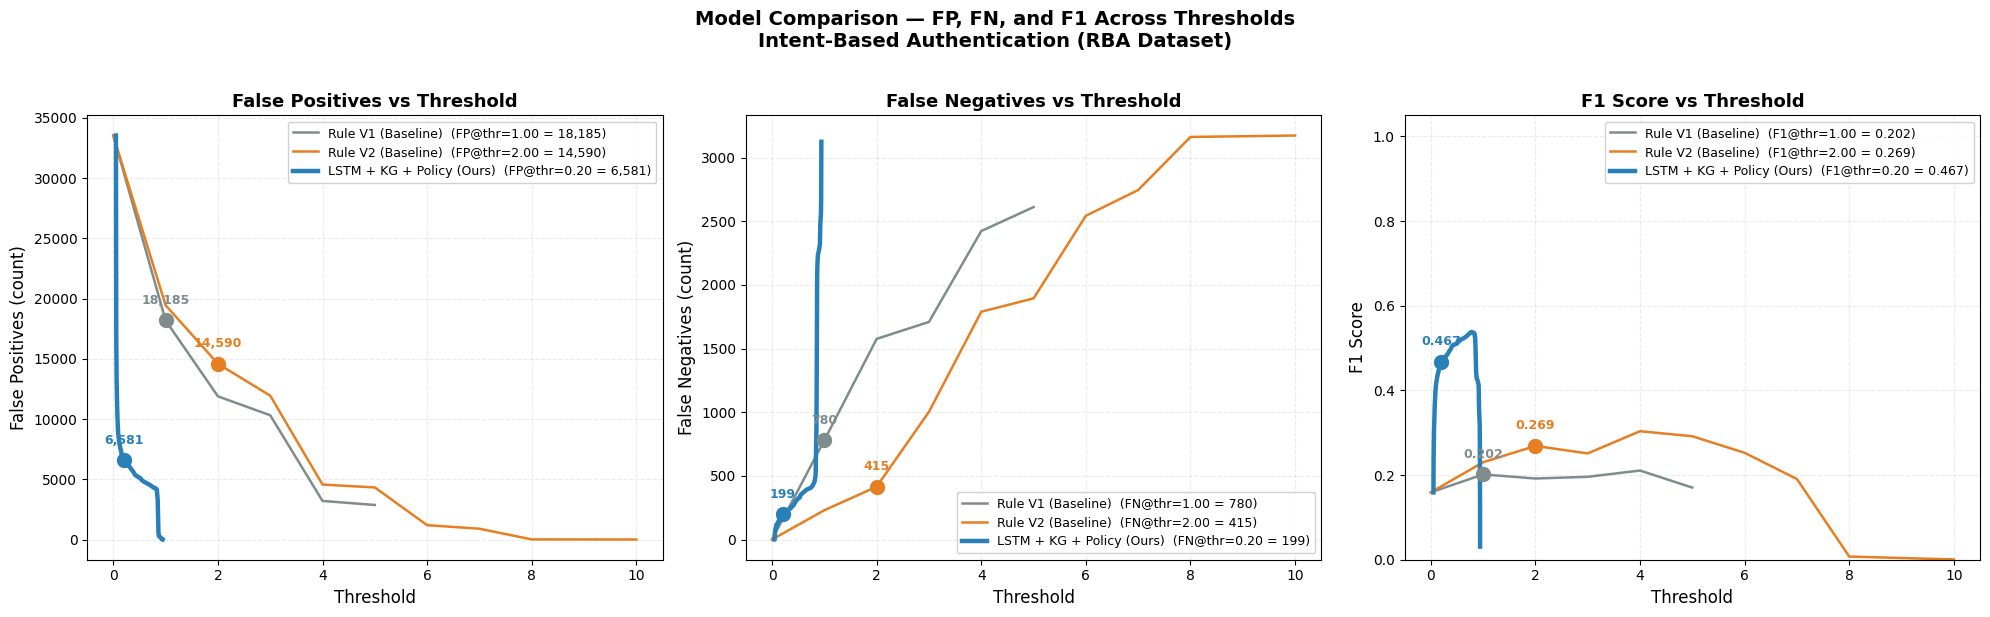

Saved: fig_fp_fn_f1_threshold.png


In [ ]:
# ── FP, FN, F1 — line charts in PR/ROC style ──
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Model Comparison — FP, FN, and F1 Across Thresholds\n'
             'Intent-Based Authentication (RBA Dataset)',
             fontsize=14, fontweight='bold', y=1.02)

named_scores = [
    ('Rule V1 (Baseline)',        y_test_rule_v1,     '#7F8C8D', 1.8),
    ('Rule V2 (Baseline)',        y_test_rule_v2,     '#E67E22', 1.8),
    ('LSTM + KG + Policy (Ours)', ensemble_test_prob, '#2980B9', 3.2),
]
thresholds_locked = [best_v1_thr, best_v2_thr, best_thr]

# ── Panel 1: FP vs Threshold ──
ax = axes[0]
for (name, scores, color, lw), thr_locked in zip(named_scores, thresholds_locked):
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test_aligned, scores)
    # FP = total predicted positive - TP
    total_pos_pred = ((scores >= thr_arr[:, None]) if False else None)

    # compute FP at each threshold directly
    fp_curve = []
    fn_curve = []
    f1_curve = []
    step = max(1, len(thr_arr) // 300)   # downsample for speed
    thr_sampled = thr_arr[::step]
    for t in thr_sampled:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_test_aligned, pred).ravel()
        fp_curve.append(fp_)
        fn_curve.append(fn_)
        p = tp_ / (tp_ + fp_ + 1e-12)
        r = tp_ / (tp_ + fn_ + 1e-12)
        f1_curve.append(2*p*r/(p+r+1e-12))

    ax.plot(thr_sampled, fp_curve, color=color, linewidth=lw,
            label=f'{name}  (FP@thr={thr_locked:.2f} = {int(evaluate_model(y_test_aligned, scores, thr_locked)["fp"]):,})')
    # mark locked threshold
    fp_at_locked = evaluate_model(y_test_aligned, scores, thr_locked)['fp']
    ax.scatter([thr_locked], [fp_at_locked], color=color, s=100, zorder=5)
    ax.annotate(f'{int(fp_at_locked):,}',
                xy=(thr_locked, fp_at_locked),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('False Positives (count)', fontsize=12)
ax.set_title('False Positives vs Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

# ── Panel 2: FN vs Threshold ──
ax = axes[1]
for (name, scores, color, lw), thr_locked in zip(named_scores, thresholds_locked):
    fn_curve = []
    thr_arr  = precision_recall_curve(y_test_aligned, scores)[2]
    step     = max(1, len(thr_arr) // 300)
    thr_sampled = thr_arr[::step]
    for t in thr_sampled:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_test_aligned, pred).ravel()
        fn_curve.append(fn_)

    ax.plot(thr_sampled, fn_curve, color=color, linewidth=lw,
            label=f'{name}  (FN@thr={thr_locked:.2f} = {int(evaluate_model(y_test_aligned, scores, thr_locked)["fn"]):,})')
    fn_at_locked = evaluate_model(y_test_aligned, scores, thr_locked)['fn']
    ax.scatter([thr_locked], [fn_at_locked], color=color, s=100, zorder=5)
    ax.annotate(f'{int(fn_at_locked):,}',
                xy=(thr_locked, fn_at_locked),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('False Negatives (count)', fontsize=12)
ax.set_title('False Negatives vs Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

# ── Panel 3: F1 vs Threshold ──
ax = axes[2]
for (name, scores, color, lw), thr_locked in zip(named_scores, thresholds_locked):
    f1_curve = []
    thr_arr  = precision_recall_curve(y_test_aligned, scores)[2]
    step     = max(1, len(thr_arr) // 300)
    thr_sampled = thr_arr[::step]
    for t in thr_sampled:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_test_aligned, pred).ravel()
        p = tp_ / (tp_ + fp_ + 1e-12)
        r = tp_ / (tp_ + fn_ + 1e-12)
        f1_curve.append(2*p*r/(p+r+1e-12))

    ax.plot(thr_sampled, f1_curve, color=color, linewidth=lw,
            label=f'{name}  (F1@thr={thr_locked:.2f} = {evaluate_model(y_test_aligned, scores, thr_locked)["f1"]:.3f})')
    f1_at_locked = evaluate_model(y_test_aligned, scores, thr_locked)['f1']
    ax.scatter([thr_locked], [f1_at_locked], color=color, s=100, zorder=5)
    ax.annotate(f'{f1_at_locked:.3f}',
                xy=(thr_locked, f1_at_locked),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_fp_fn_f1_threshold.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_fp_fn_f1_threshold.png")

FP / FN reduction (bar + line + % annotation)


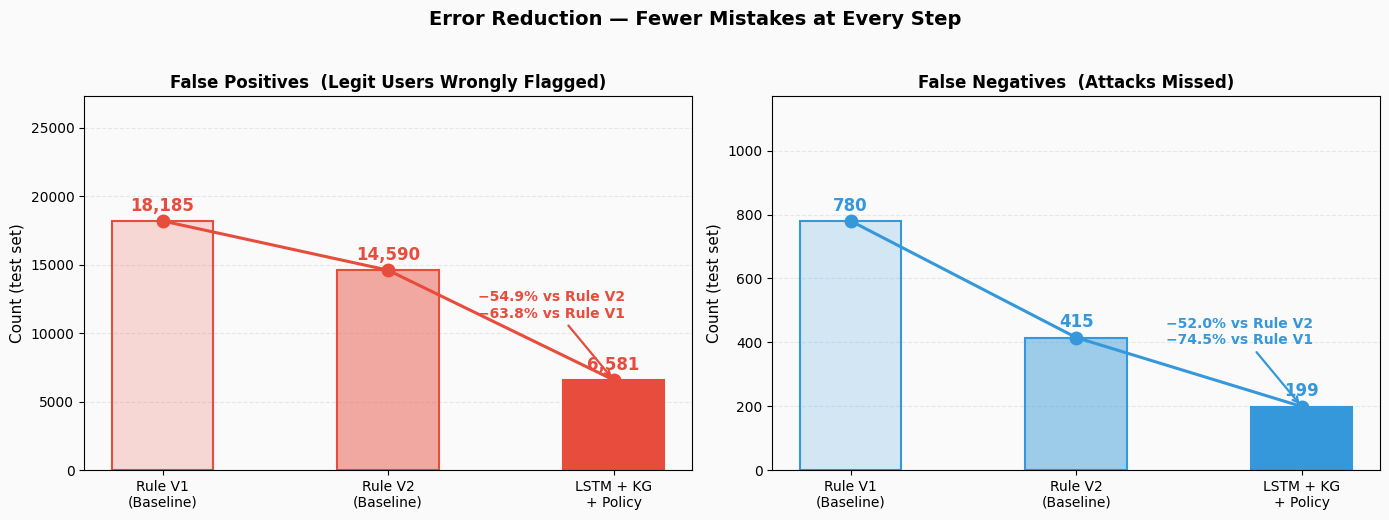

Saved: fig4_fp_fn_reduction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Error Reduction — Fewer Mistakes at Every Step',
             fontsize=14, fontweight='bold', y=1.03)

stages_short = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']

for ax, key, title, color in zip(
    axes,
    ['fp', 'fn'],
    ['False Positives  (Legit Users Wrongly Flagged)',
     'False Negatives  (Attacks Missed)'],
    ['#E74C3C', '#3498DB']
):
    vals = [rule_v1_m[key], rule_v2_m[key], ens_m[key]]
    bars = ax.bar(stages_short, vals,
                  color=[f'{color}33', f'{color}77', color],
                  edgecolor=color, linewidth=1.5, width=0.45, zorder=2)
    ax.plot(stages_short, vals, marker='o', color=color,
            linewidth=2.2, markersize=9, zorder=3)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.025,
                f'{int(v):,}', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color=color)

    pct_v2 = (vals[1] - vals[2]) / vals[1] * 100
    pct_v1 = (vals[0] - vals[2]) / vals[0] * 100
    ax.annotate(
        f'−{pct_v2:.1f}% vs Rule V2\n−{pct_v1:.1f}% vs Rule V1',
        xy=(2, vals[2]),
        xytext=(1.4, vals[2] + max(vals) * 0.25),
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.6)
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count (test set)', fontsize=11)
    ax.set_ylim(0, max(vals) * 1.5)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('fig4_fp_fn_reduction.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig4_fp_fn_reduction.png")

Line chart (3 lines, your professor's specific request)

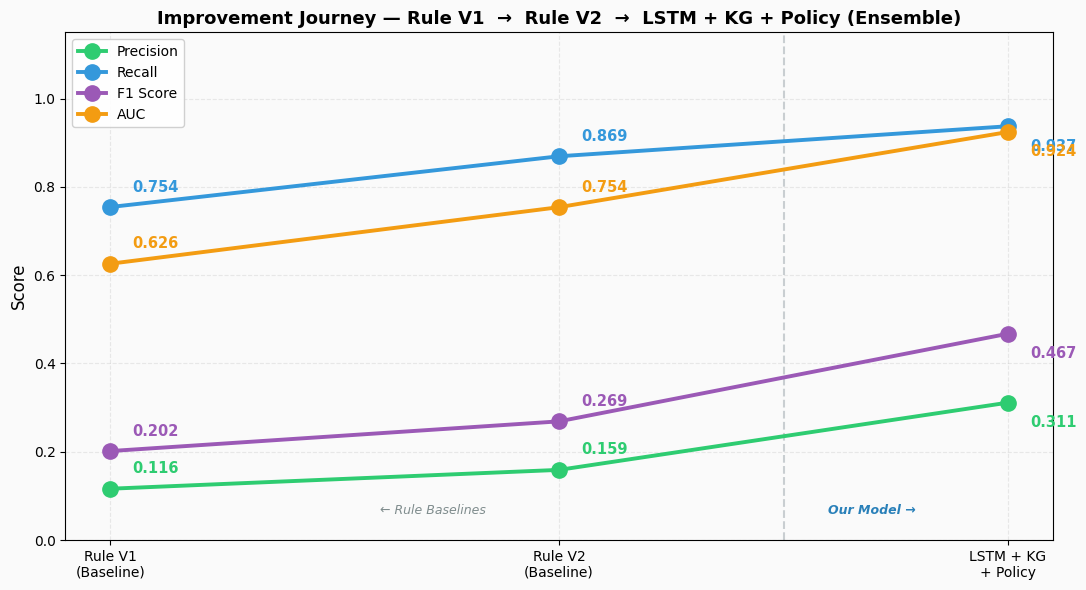

Saved: fig2_improvement_journey.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

stages = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']

journey = {
    'Precision': ('#2ECC71',  [rule_v1_m['precision'], rule_v2_m['precision'], ens_m['precision']]),
    'Recall':    ('#3498DB',  [rule_v1_m['recall'],    rule_v2_m['recall'],    ens_m['recall']]),
    'F1 Score':  ('#9B59B6',  [rule_v1_m['f1'],        rule_v2_m['f1'],        ens_m['f1']]),
    'AUC':       ('#F39C12',  [rule_v1_m['auc'],       rule_v2_m['auc'],       ens_m['auc']]),
}

for metric, (color, vals) in journey.items():
    ax.plot(stages, vals, marker='o', linewidth=2.8, markersize=11,
            label=metric, color=color, zorder=3)
    for i, v in enumerate(vals):
        offset = 0.035 if i < 2 else -0.055
        ax.annotate(f'{v:.3f}',
                    xy=(i, v), xytext=(i + 0.05, v + offset),
                    fontsize=10.5, fontweight='bold', color=color)

# divider before our model
ax.axvline(1.5, color='#BDC3C7', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(0.6, 0.06, '← Rule Baselines', fontsize=9, color='#7F8C8D', style='italic')
ax.text(1.6, 0.06, 'Our Model →',      fontsize=9, color='#2980B9', style='italic',
        fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Improvement Journey — Rule V1  →  Rule V2  →  LSTM + KG + Policy (Ensemble)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('fig2_improvement_journey.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig2_improvement_journey.png")

Grouped bar (all 6 metrics)

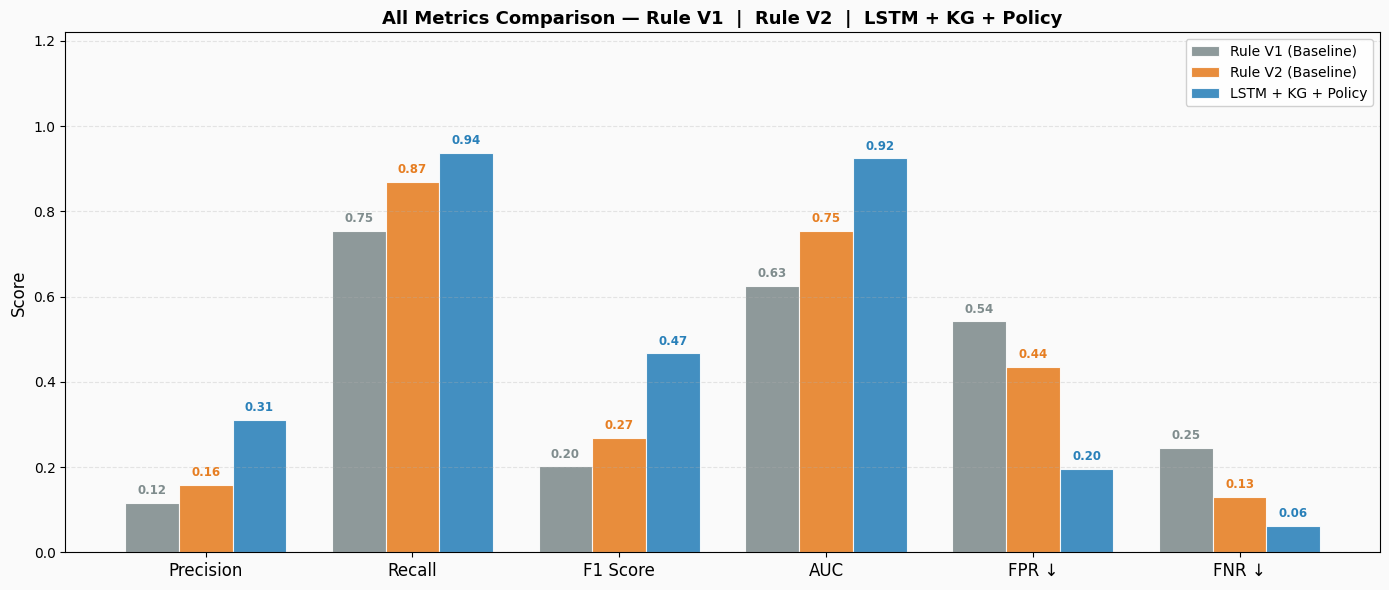

Saved: fig3_metrics_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

model_names  = ['Rule V1 (Baseline)', 'Rule V2 (Baseline)', 'LSTM + KG + Policy']
bar_colors   = ['#7F8C8D', '#E67E22', '#2980B9']
metric_names = ['Precision', 'Recall', 'F1 Score', 'AUC', 'FPR ↓', 'FNR ↓']
metric_keys  = ['precision', 'recall', 'f1', 'auc', 'fpr', 'fnr']
model_results = [rule_v1_m, rule_v2_m, ens_m]

x     = np.arange(len(metric_names))
width = 0.26

for i, (name, color, res) in enumerate(zip(model_names, bar_colors, model_results)):
    vals = [res[k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.013,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.22)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'All Metrics Comparison — Rule V1  |  Rule V2  |  LSTM + KG + Policy',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig3_metrics_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig3_metrics_comparison.png")

PR curve + ROC curve

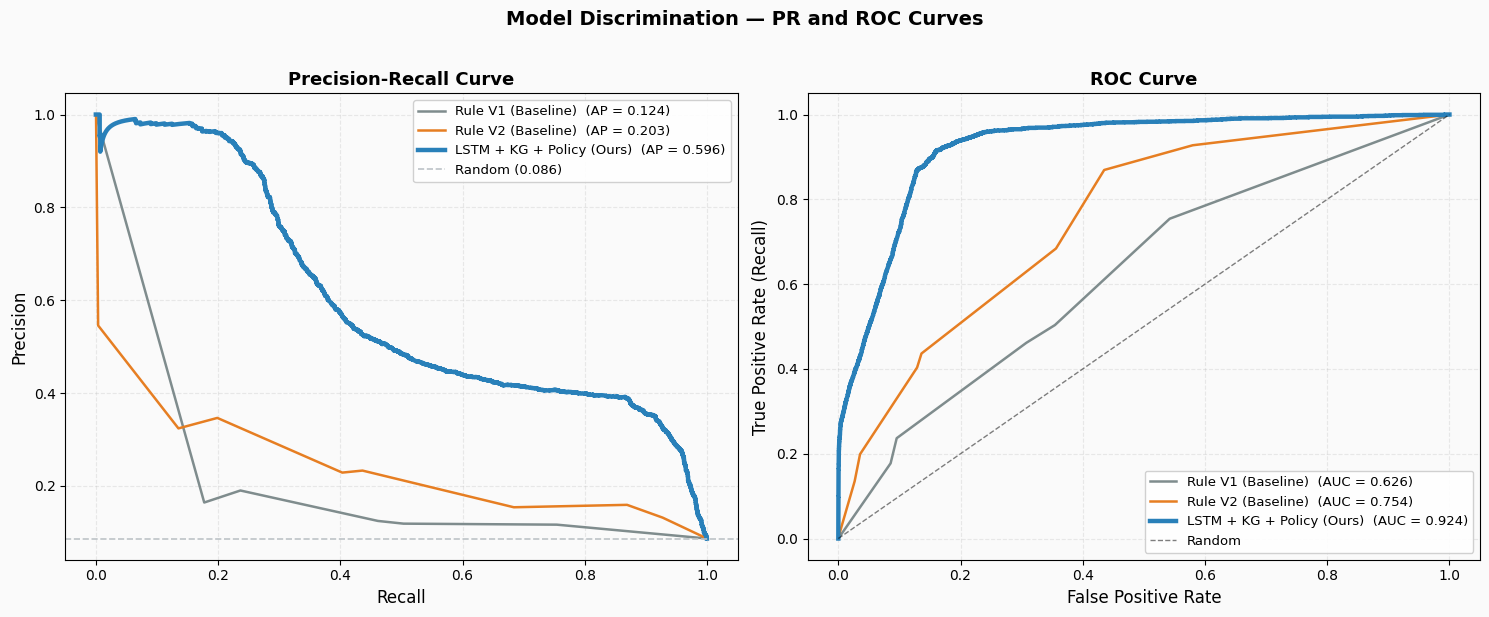

Saved: fig5_pr_roc_curves.png


In [ ]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              roc_curve, roc_auc_score)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#FAFAFA')

named_scores = [
    ('Rule V1 (Baseline)',         y_test_rule_v1,     '#7F8C8D', 1.8),
    ('Rule V2 (Baseline)',         y_test_rule_v2,     '#E67E22', 1.8),
    ('LSTM + KG + Policy (Ours)',  ensemble_test_prob, '#2980B9', 3.2),
]

for name, scores, color, lw in named_scores:
    prec_c, rec_c, _ = precision_recall_curve(y_test_aligned, scores)
    ap = average_precision_score(y_test_aligned, scores)
    axes[0].plot(rec_c, prec_c, color=color, linewidth=lw,
                 label=f'{name}  (AP = {ap:.3f})')

axes[0].axhline(y_test_aligned.mean(), color='#BDC3C7', linestyle='--',
                linewidth=1.2, label=f'Random ({y_test_aligned.mean():.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9.5, framealpha=0.9)
axes[0].grid(True, alpha=0.25, linestyle='--')
axes[0].set_facecolor('#FAFAFA')

for name, scores, color, lw in named_scores:
    fpr_c, tpr_c, _ = roc_curve(y_test_aligned, scores)
    auc_val = roc_auc_score(y_test_aligned, scores)
    axes[1].plot(fpr_c, tpr_c, color=color, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.3f})')

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random', alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9.5, framealpha=0.9)
axes[1].grid(True, alpha=0.25, linestyle='--')
axes[1].set_facecolor('#FAFAFA')

plt.suptitle('Model Discrimination — PR and ROC Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_pr_roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig5_pr_roc_curves.png")

Publication summary table


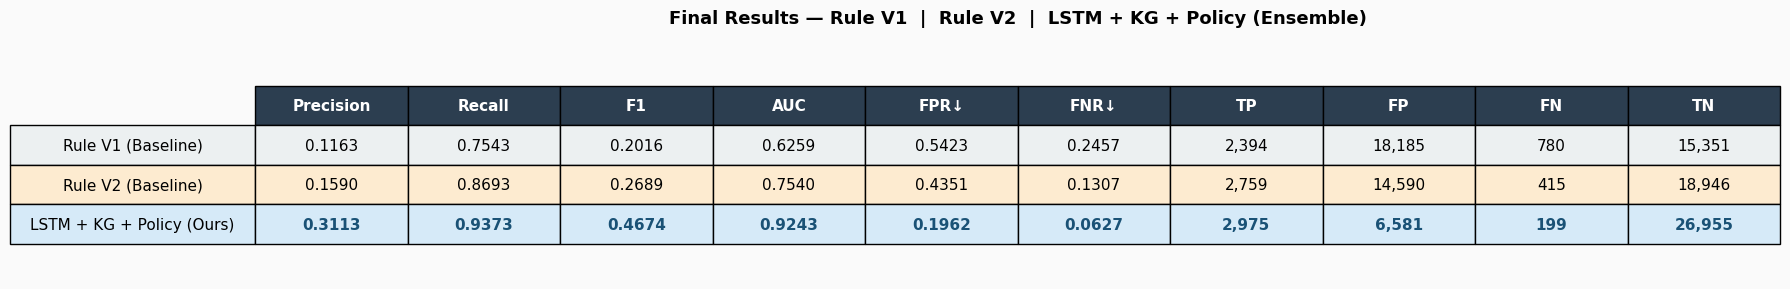

Saved: fig6_results_table.png


In [ ]:
rows = {
    'Rule V1 (Baseline)':        rule_v1_m,
    'Rule V2 (Baseline)':        rule_v2_m,
    'LSTM + KG + Policy (Ours)': ens_m,
}
display_cols = ['precision','recall','f1','auc','fpr','fnr','tp','fp','fn','tn']
col_labels   = ['Precision','Recall','F1','AUC','FPR↓','FNR↓','TP','FP','FN','TN']

table_data = []
for m in rows.values():
    row = []
    for c in display_cols:
        v = m[c]
        row.append(f'{v:.4f}' if isinstance(v, float) else f'{int(v):,}')
    table_data.append(row)

fig, ax = plt.subplots(figsize=(18, 3))
fig.patch.set_facecolor('#FAFAFA')
ax.axis('off')

tbl = ax.table(
    cellText  = table_data,
    rowLabels = list(rows.keys()),
    colLabels = col_labels,
    cellLoc   = 'center',
    rowLoc    = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 2.4)

# header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# row colours
row_colors = ['#ECF0F1', '#FDEBD0', '#D6EAF8']
for i, rc in enumerate(row_colors):
    tbl[i+1, -1].set_facecolor(rc)
    for j in range(len(col_labels)):
        tbl[i+1, j].set_facecolor(rc)

# bold our model
for j in range(len(col_labels)):
    tbl[3, j].set_text_props(fontweight='bold', color='#1A5276')

ax.set_title(
    'Final Results — Rule V1  |  Rule V2  |  LSTM + KG + Policy (Ensemble)',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('fig6_results_table.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig6_results_table.png")

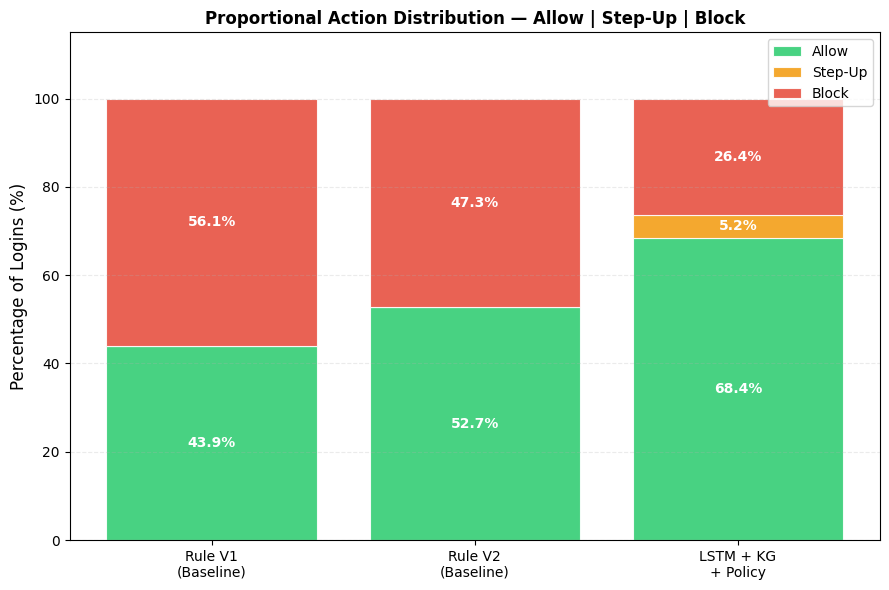

Saved: fig_action_distribution_pct.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')

model_labels  = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']
action_colors = {'Allow': '#2ECC71', 'Step-Up': '#F39C12', 'Block': '#E74C3C'}
models_list   = list(all_ac.values())

bottoms = np.zeros(3)
totals  = np.array([ac['Allow'] + ac['Step-Up'] + ac['Block']
                    for ac in models_list], dtype=float)

for action, color in action_colors.items():
    raw  = np.array([ac[action] for ac in models_list], dtype=float)
    vals = raw / totals * 100

    bars = ax.bar(model_labels, vals, bottom=bottoms,
                  color=color, label=action,
                  alpha=0.88, edgecolor='white', linewidth=0.8)

    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 1.5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f'{v:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms += vals

ax.set_ylabel('Percentage of Logins (%)', fontsize=12)
ax.set_title('Proportional Action Distribution — Allow | Step-Up | Block',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('fig_action_distribution_pct.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_action_distribution_pct.png")

In [113]:
!git add .

!git config --global user.email "madhuchokshi23@gmail.com"
!git config --global user.name "madhvesh23"

In [114]:
!git commit -m "LSTM +KG + XGBoost Final Verdict"

[intent_v2 730551d] LSTM +KG + XGBoost Final Verdict
 33 files changed, 11 insertions(+), 3 deletions(-)
 create mode 100644 best_model.keras
 create mode 100644 fig1_confusion_matrices.png
 create mode 100644 fig2_improvement_journey.png
 create mode 100644 fig3_metrics_comparison.png
 create mode 100644 fig4_fp_fn_reduction.png
 create mode 100644 fig5_pr_roc_curves.png
 create mode 100644 fig6_results_table.png
 create mode 100644 fig_action_distribution_pct.png
 create mode 100644 fig_fp_fn_f1_threshold.png
 create mode 100644 fig_fp_line.png
 create mode 100644 final_comparison_table.csv
 create mode 100644 lstm_kg_final_model.keras
 create mode 100644 lstm_thresholds.json
 create mode 100644 lstm_training_history.json
 create mode 100644 meta_clf.pkl
 create mode 100644 meta_scaler.pkl
 create mode 100644 model_comparison_table.png
 rewrite notebooks/02_rule_baseline.ipynb (86%)
 create mode 100644 notebooks/03_Boosting, KG & LSTM.ipynb
 delete mode 100644 notebooks/03_train_kg_a

In [116]:
!git push origin intent_v2

remote: Invalid username or token. Password authentication is not supported for Git operations.
fatal: Authentication failed for 'https://github.com/madhvesh23/Intent-Classification-ML-Project-.git/'
